In [1]:
import os
import pandas as pd
import numpy as np
from tqdm import tqdm
import re
import warnings
import pandas as pd
from pymfe.mfe import MFE
from sklearn.impute import SimpleImputer

def fill_missing_values_simple(data, strategy='mode'):
    """
    Простое заполнение пропусков
    """
    data_filled = data.copy()
    
    # Разделяем числовые и категориальные признаки
    numeric_cols = data_filled.select_dtypes(include=[np.number]).columns
    categorical_cols = data_filled.select_dtypes(include=['object']).columns
    
    # Заполняем числовые признаки
    if len(numeric_cols) > 0:
        if strategy == 'mean':
            imputer = SimpleImputer(strategy='mean')
        elif strategy == 'median':
            imputer = SimpleImputer(strategy='median')
        elif strategy == 'mode':
            imputer = SimpleImputer(strategy='most_frequent')
        elif strategy == 'constant':
            imputer = SimpleImputer(strategy='constant', fill_value=0)
        
        data_filled[numeric_cols] = imputer.fit_transform(data_filled[numeric_cols])
    
    # Заполняем категориальные признаки модой
    if len(categorical_cols) > 0:
        imputer_cat = SimpleImputer(strategy='most_frequent')
        data_filled[categorical_cols] = imputer_cat.fit_transform(data_filled[categorical_cols])
    
    return data_filled
dic = {'MAR_5':1, 'MAR_15':2, 'MAR_30':3, 'MAR_50':4,
                'MCAR_5':5, 'MCAR_15':6, 'MCAR_30':7, 'MCAR_50':8,
                'MNAR_5':9, 'MNAR_15':10, 'MNAR_30':11, 'MNAR_50':12}
def result(table, input_path, data, folder_name, filename):
    
    data = fill_missing_values_simple(data)
    procent = folder_name.split('_')[1]
    feautures = [col for col in data.columns if col != 'Target']
    X = data[feautures]
    y = data['Target']

    safe_features: List[str] = [
        # --- General ---
        "nr_inst", "nr_attr", "nr_num",
        
        # --- Statistical ---
        "iq_range", "mad", "max", "mean", "median",
        "min", "nr_outliers", "range", "sd",
        "sparsity", "t_mean", "var",

        # --- Info-Theory (Добавляем только быстрые!) ---
        "attr_ent",    # Энтропия признаков
        "class_ent",   # Энтропия классов
        "ns_ratio",    # Отношение шум-сигнал
        "eq_num_attr"  # Эквивалентное число признаков
    ]

    # Инициализация MFE.
    # Возвращаемся к стандартным, документированным параметрам.
    mfe = MFE(
        features=safe_features,
        groups=["general", "statistical", "info-theory"], 
        summary=["mean", "sd"],
        random_state=42,
        suppress_warnings=True # Подавляем лишние предупреждения
    )

    # Выполнение
    try:
        # Pymfe требует numpy массивы
        mfe.fit(X.values, y.values, precomp_groups=None)
        ft = mfe.extract()
    except MemoryError as e:
        print(f"ОШИБКА ПАМЯТИ: MFE не смог вычислить признаки. Сообщение: {e}")
        # В случае ошибки возвращаем пустой набор признаков (для избежания падения)
        feature_names = [f"{f}_mean" for f in safe_features] + [f"{f}_sd" for f in safe_features]
        ft = (feature_names, [0.0] * len(feature_names)) 
    
    d = dict(zip(ft[0], ft[1]))
    d['procent_propusk'] = int(procent)
    # Используем исходное значение метода
    d['type_propusk'] = int(dic[folder_name])
    d['name_dataset'] = filename
    
    
    # Создаем DataFrame из словаря и объединяем
    stroka = pd.DataFrame([d])

    table = pd.concat([table, stroka], ignore_index=True)
    return table

'''
dic = {'MAR_5':1, 'MAR_15':2, 'MAR_30':3, 'MAR_50':4,
                'MCAR_5':5, 'MCAR_15':6, 'MCAR_30':7, 'MCAR_50':8,
                'MNAR_5':9, 'MNAR_15':10, 'MNAR_30':11, 'MNAR_50':12}

def result(table, input_path, data, folder_name, filename):
    # 1. СЭМПЛИРОВАНИЕ (Безопасное)
    # Берем 5000 строк только если их реально больше 5000
    n_samples = min(len(data), 5000)
    if len(data) > 5000:
        data = data.sample(n=5000, random_state=42)
        
    # Разделяем на признаки и таргет
    features_cols = [col for col in data.columns if col != 'Target']
    X = data[features_cols]
    y = data['Target']
    # --- ЭТАП 1: Исходный датасет (без пропусков) ---
    # Общие признаки (General)
    general_features = [
        "nr_inst", "nr_attr", "nr_bin", "inst_to_attr", 
        "attr_to_inst", "freq_class", "nr_class", "nr_num"
    ]
    
    mfe_gen = MFE(features=general_features, groups=["general"], suppress_warnings=True)
    mfe_gen.fit(X.values, y.values)
    ft_gen = mfe_gen.extract()
    
    # Признаки теории информации (Info-theory)
    info_theory_safe = [
        "class_ent",     # Энтропия классов (насколько сбалансированы цели)
        "eq_num_attr"   # Эквивалентное число признаков    
    ]
    mfe_info = MFE(features = info_theory_safe, groups=["info-theory"], suppress_warnings=True)
    mfe_info.fit(X.values, y.values)
    ft_info = mfe_info.extract()
    
    # --- ЭТАП 2: Работа с пропусками ---
    # Создаём объект SimpleImputer с стратегией 'most_frequent'
    imputer = SimpleImputer(strategy='mean')

    # Вменяем пропущенные значения
    X_imputed = imputer.fit_transform(X)
    # 2. ПРИНУДИТЕЛЬНОЕ ПРИВЕДЕНИЕ ТИПА (Ключевой шаг)
    X_imputed = np.ascontiguousarray(X_imputed, dtype=float)
    
    # Статистические признаки (Statistical)
    safe_statistical = [
        "mean", "median", "min", "max", "range", 
        "sd", "var", "iq_range", "mad", "sparsity", "nr_outliers"
    ]
    
    mfe_stat = MFE(features=safe_statistical, groups=["statistical"], suppress_warnings=True)
    mfe_stat.fit(X_imputed, y.values)
    ft_stat = mfe_stat.extract()
    
    # --- ЭТАП 3: Сборка результатов ---
    # Собираем всё в один словарь
    d = {}
    
    # Объединяем результаты всех трех экстракций
    for names, values in [ft_gen, ft_info, ft_stat]:
        # Заменяем nan на 0.0 сразу при сборке
        clean_values = np.nan_to_num(values, nan=0.0)
        d.update(zip(names, clean_values))
    
    # Добавляем мета-информацию
    procent = folder_name.split('_')[1] if '_' in folder_name else "0"
    d['procent_propusk'] = int(procent)
    d['type_propusk'] = int(dic[folder_name])
    d['name_dataset'] = filename
    
    # Создаем строку и добавляем в общую таблицу
    stroka = pd.DataFrame([d])
    table = pd.concat([table, stroka], ignore_index=True)
    
    return table
'''
'''
def result(table, input_path, data, folder_name, filename):
    # 1. СЭМПЛИРОВАНИЕ (Безопасное)
    # Берем 5000 строк только если их реально больше 5000
    n_samples = min(len(data), 5000)
    if len(data) > n_samples:
        data = data.sample(n=n_samples, random_state=42)

    features_cols = [col for col in data.columns if col != 'Target']
    X = data[features_cols]
    y = data['Target']

    # 2. ПОДГОТОВКА ДАННЫХ
    imputer = SimpleImputer(strategy='most_frequent')
    X_imputed = imputer.fit_transform(X)
    X_imputed = np.ascontiguousarray(X_imputed, dtype=float)

    # 3. СПИСОК ФИЧЕЙ (General + Statistical + Safe Info-Theory)
    selected_features = [
        # General
        "nr_inst", "nr_attr", "nr_bin", "inst_to_attr", "attr_to_inst", "nr_class", "nr_num", "freq_class",
        # Statistical (Без nr_outliers для скорости)
        "mean", "median", "min", "max", "range", "sd", "var", "iq_range", "mad", "sparsity",
        # Info-Theory (Только безопасные из вашего списка)
        "class_ent", "eq_num_attr"
    ]

    mfe = MFE(features=selected_features, suppress_warnings=True)
    
    try:
        mfe.fit(X_imputed, y.values)
        ft_names, ft_values = mfe.extract()
        res_dict = dict(zip(ft_names, np.nan_to_num(ft_values, nan=0.0)))
    except Exception as e:
        print(f"Ошибка на файле {filename}: {e}")
        return table

    # 4. МЕТА-ИНФОРМАЦИЯ
    procent = folder_name.split('_')[1] if '_' in folder_name else "0"
    res_dict['procent_propusk'] = int(procent)
    res_dict['type_propusk'] = MISSING_TYPE_MAP.get(folder_name, 0)
    res_dict['name_dataset'] = filename

    stroka = pd.DataFrame([res_dict])
    return pd.concat([table, stroka], ignore_index=True)
'''
def process_folder(table, input_folder, folder_name):
    """Обрабатывает все CSV-файлы с прогресс-баром"""
    files = [f for f in os.listdir(input_folder) if f.endswith('.csv')]
    with tqdm(total=len(files), desc="Обработка файлов") as pbar:
        processed_files = 0
        for filename in files:
            input_path = os.path.join(input_folder, filename)
            data = pd.read_csv(input_path)

            table = result(table, filename, data, folder_name, filename)
            processed_files += 1
            pbar.update(1)
    table.to_csv('META2_dataset.csv', index=False)

    print(f"\nГотово! Обработано {processed_files}/{len(files)} файлов")
    return table


def process_all_folders(table, base_input_folder, folder_names):
    """Обрабатывает все указанные папки"""
    for folder_name in folder_names:
        input_folder = os.path.join(
            base_input_folder, folder_name)

        print(f"\nОбработка папки: {folder_name}")
        print(f"Входная папка: {input_folder}")

        if os.path.exists(input_folder):
            # Сохраняем обновленную таблицу
            table = process_folder(table, input_folder, folder_name)
            # Сохраняем после каждой папки для безопасности
            table.to_csv('META2_dataset.csv', index=False)
            print(f"Результаты папки {folder_name} сохранены")
        else:
            print(f"Папка {input_folder} не существует, пропускаем")

    return table  # Возвращаем итоговую таблицу


# Установка seed для воспроизводимости
np.random.seed(42)

# Список папок для обработки
folder_names = ['MAR_5', 'MAR_15', 'MAR_30', 'MAR_50',
                'MCAR_5', 'MCAR_15', 'MCAR_30', 'MCAR_50',
                'MNAR_5', 'MNAR_15', 'MNAR_30', 'MNAR_50']

table = pd.DataFrame()
# Базовый путь к данным
base_input_folder = r'D:\Data'
table = process_all_folders(table, base_input_folder, folder_names)

# Финальное сохранение
table.to_csv('META1_dataset.csv', index=False)
print("\nВсе папки обработаны! Итоговая таблица сохранена.")

"""
table = pd.read_csv('Meta_dataset.csv')
# Базовый путь к данным
base_input_folder = r'D:\Data'
table = process_all_folders(table, base_input_folder, folder_names)

# Финальное сохранение
table.to_csv('Meta_dataset.csv', index=False)
print("\nВсе папки обработаны! Итоговая таблица сохранена.")
"""

<>:280: SyntaxWarning: invalid escape sequence '\D'
<>:280: SyntaxWarning: invalid escape sequence '\D'
C:\Users\nikit\AppData\Local\Temp\ipykernel_10964\2895806193.py:280: SyntaxWarning: invalid escape sequence '\D'
  """



Обработка папки: MAR_5
Входная папка: D:\Data\MAR_5


Обработка файлов:   0%|                                                                         | 0/96 [00:00<?, ?it/s]C:\Users\nikit\AppData\Local\Programs\Python\Python312\Lib\site-packages\pymfe\_internal.py:1567: UserWarning: It is not possible make equal discretization
  warnings.warn("It is not possible make equal discretization")
Обработка файлов:   1%|▋                                                                | 1/96 [00:00<00:34,  2.73it/s]C:\Users\nikit\AppData\Local\Programs\Python\Python312\Lib\site-packages\pymfe\_internal.py:1567: UserWarning: It is not possible make equal discretization
  warnings.warn("It is not possible make equal discretization")
Обработка файлов:   2%|█▎                                                               | 2/96 [00:08<07:47,  4.98s/it]C:\Users\nikit\AppData\Local\Programs\Python\Python312\Lib\site-packages\pymfe\_internal.py:1567: UserWarning: It is not possible make equal discretization
  warnings.warn("It is not possible make equal 


Готово! Обработано 96/96 файлов
Результаты папки MAR_5 сохранены

Обработка папки: MAR_15
Входная папка: D:\Data\MAR_15


Обработка файлов:   0%|                                                                         | 0/96 [00:00<?, ?it/s]C:\Users\nikit\AppData\Local\Programs\Python\Python312\Lib\site-packages\pymfe\_internal.py:1567: UserWarning: It is not possible make equal discretization
  warnings.warn("It is not possible make equal discretization")
Обработка файлов:   1%|▋                                                                | 1/96 [00:00<00:33,  2.84it/s]C:\Users\nikit\AppData\Local\Programs\Python\Python312\Lib\site-packages\pymfe\_internal.py:1567: UserWarning: It is not possible make equal discretization
  warnings.warn("It is not possible make equal discretization")
Обработка файлов:   2%|█▎                                                               | 2/96 [00:08<07:47,  4.98s/it]C:\Users\nikit\AppData\Local\Programs\Python\Python312\Lib\site-packages\pymfe\_internal.py:1567: UserWarning: It is not possible make equal discretization
  warnings.warn("It is not possible make equal 

...

Обработка файлов:   0%|                                                                         | 0/96 [00:00<?, ?it/s]C:\Users\nikit\AppData\Local\Programs\Python\Python312\Lib\site-packages\pymfe\_internal.py:1567: UserWarning: It is not possible make equal discretization
  warnings.warn("It is not possible make equal discretization")
Обработка файлов:   1%|▋                                                                | 1/96 [00:00<00:35,  2.67it/s]C:\Users\nikit\AppData\Local\Programs\Python\Python312\Lib\site-packages\pymfe\_internal.py:1567: UserWarning: It is not possible make equal discretization
  warnings.warn("It is not possible make equal discretization")
Обработка файлов:   2%|█▎                                                               | 2/96 [00:08<07:46,  4.96s/it]C:\Users\nikit\AppData\Local\Programs\Python\Python312\Lib\site-packages\pymfe\_internal.py:1567: UserWarning: It is not possible make equal discretization
  warnings.warn("It is not possible make equal 


Готово! Обработано 96/96 файлов
Результаты папки MNAR_30 сохранены

Обработка папки: MNAR_50
Входная папка: D:\Data\MNAR_50


Обработка файлов:   0%|                                                                         | 0/96 [00:00<?, ?it/s]C:\Users\nikit\AppData\Local\Programs\Python\Python312\Lib\site-packages\pymfe\_internal.py:1567: UserWarning: It is not possible make equal discretization
  warnings.warn("It is not possible make equal discretization")
Обработка файлов:   1%|▋                                                                | 1/96 [00:00<00:32,  2.91it/s]C:\Users\nikit\AppData\Local\Programs\Python\Python312\Lib\site-packages\pymfe\_internal.py:1567: UserWarning: It is not possible make equal discretization
  warnings.warn("It is not possible make equal discretization")
Обработка файлов:   2%|█▎                                                               | 2/96 [00:08<07:40,  4.90s/it]C:\Users\nikit\AppData\Local\Programs\Python\Python312\Lib\site-packages\pymfe\_internal.py:1567: UserWarning: It is not possible make equal discretization
  warnings.warn("It is not possible make equal 


Готово! Обработано 96/96 файлов
Результаты папки MNAR_50 сохранены

Все папки обработаны! Итоговая таблица сохранена.


'\ntable = pd.read_csv(\'Meta_dataset.csv\')\n# Базовый путь к данным\nbase_input_folder = r\'D:\\Data\'\ntable = process_all_folders(table, base_input_folder, folder_names)\n\n# Финальное сохранение\ntable.to_csv(\'Meta_dataset.csv\', index=False)\nprint("\nВсе папки обработаны! Итоговая таблица сохранена.")\n'

In [31]:
data = pd.read_csv('Meta_dataset.csv')

In [32]:
table['type_propusk'] = data['type_propusk']
table['method_zapolnenia'] = data['method_zapolnenia']


In [33]:
table.to_csv('META1_dataset.csv', index=False)


In [23]:
import pandas as pd
from pymfe.mfe import MFE
from typing import List, Dict, Any
import numpy as np
np.random.seed(42)


    
data = pd.read_csv('2dplanes_binclass_binaryClass.csv')
feautures = [col for col in data.columns if col != 'Target']
X = data[feautures]
y = data['Target']

# Исключаем проблемные и медленные мета-признаки
safe_features: List[str] = [
    "nr_inst", "nr_attr", "nr_num",
    "iq_range", "mad", "max", "mean", "median",
    "min", "nr_outliers", "range", "sd",
    "sparsity", "t_mean", "var",
    ]

    # Инициализация MFE.
    # Возвращаемся к стандартным, документированным параметрам.
mfe = MFE(
        features=safe_features,
        groups=["general", "statistical"], # <-- Правильный способ исключить info-theory
        summary=["mean", "sd"],
        random_state=42,
        suppress_warnings=True # Подавляем лишние предупреждения
    )

mfe.fit(X.values, y.values, precomp_groups=None)
ft = mfe.extract()
print(ft)

(['iq_range.mean', 'iq_range.sd', 'mad.mean', 'mad.sd', 'max.mean', 'max.sd', 'mean.mean', 'mean.sd', 'median.mean', 'median.sd', 'min.mean', 'min.sd', 'nr_attr', 'nr_inst', 'nr_num', 'nr_outliers', 'range.mean', 'range.sd', 'sd.mean', 'sd.sd', 'sparsity.mean', 'sparsity.sd', 't_mean.mean', 't_mean.sd', 'var.mean', 'var.sd'], [1.999999992, 4.7328638364993184e-08, 1.4727159816258235, 0.031255916417594176, 1.0000000039999999, 3.864367133347658e-08, 0.0015943925167045657, 0.004954762424158732, 0.006666660970010806, 0.02108183315875292, -0.9999999880000001, 2.529822126803117e-08, 10, 40768, 10, 0, 1.999999992, 4.7328638364993184e-08, 0.8152922256394118, 0.0566081281794844, 0.01109575634622995, 0.003021236799866458, 0.0026571851718179954, 0.008257527259588405, 0.6675854453464523, 0.1004039064570091])


C:\Users\nikit\AppData\Local\Programs\Python\Python312\Lib\site-packages\pymfe\_internal.py:1567: UserWarning: It is not possible make equal discretization
  warnings.warn("It is not possible make equal discretization")


In [24]:
len(ft[0])

26

In [25]:
dic = dict(zip(ft[0], ft[1]))

print(dic)

{'iq_range.mean': 1.999999992, 'iq_range.sd': 4.7328638364993184e-08, 'mad.mean': 1.4727159816258235, 'mad.sd': 0.031255916417594176, 'max.mean': 1.0000000039999999, 'max.sd': 3.864367133347658e-08, 'mean.mean': 0.0015943925167045657, 'mean.sd': 0.004954762424158732, 'median.mean': 0.006666660970010806, 'median.sd': 0.02108183315875292, 'min.mean': -0.9999999880000001, 'min.sd': 2.529822126803117e-08, 'nr_attr': 10, 'nr_inst': 40768, 'nr_num': 10, 'nr_outliers': 0, 'range.mean': 1.999999992, 'range.sd': 4.7328638364993184e-08, 'sd.mean': 0.8152922256394118, 'sd.sd': 0.0566081281794844, 'sparsity.mean': 0.01109575634622995, 'sparsity.sd': 0.003021236799866458, 't_mean.mean': 0.0026571851718179954, 't_mean.sd': 0.008257527259588405, 'var.mean': 0.6675854453464523, 'var.sd': 0.1004039064570091}


In [26]:
cols = ft[0]
cols.append('procent_propusk')
cols.append('type_propusk')
table = pd.DataFrame([cols])
table.to_csv('Meta_dataset.csv', index = False)

In [28]:
table = pd.read_csv('Meta_dataset.csv')
table = table.iloc[1:]

table.to_csv('Meta_dataset.csv', index = False)

In [29]:
table = table.iloc[:,29:]

table.to_csv('Meta_dataset.csv', index = False)

In [30]:
table = table.iloc[:,1:]

table.to_csv('Meta_dataset.csv', index = False)

In [32]:
import pandas as pd

table1 = pd.read_csv('linear.csv')
table1.columns

Index(['type_propusk', 'method_zapolnenia', 'name_dataset', 'model', 'RMSE',
       'MAE', 'R2', 'Accuracy', 'Precision', 'Recall', 'F1', 'fit_time',
       'time_score'],
      dtype='object')

In [34]:
table1 = table1[['type_propusk', 'method_zapolnenia', 'name_dataset', 'R2', 'F1']]
table1.to_csv('Meta_linear.csv', index = False)

In [35]:
table2 = pd.read_csv('random_forest.csv')
table2 = table2[['type_propusk', 'method_zapolnenia', 'name_dataset', 'R2', 'F1']]
table2.to_csv('Meta_random_forest.csv', index = False)

In [36]:
table3 = pd.read_csv('xgboost.csv')
table3 = table3[['type_propusk', 'method_zapolnenia', 'name_dataset', 'R2', 'F1']]
table3.to_csv('Meta_xgboost.csv', index = False)

In [37]:
print(len(table1),len(table2),len(table3))

6298 6298 6246


In [40]:
import pandas as pd
import numpy as np

df = pd.read_csv("Meta_linear.csv")

# 1. Замена пустых строк (NaN) в F1 и R2 на 0 для корректного сравнения.
# F1 используется для классификации (где R2 - пустой), R2 - для регрессии (где F1 - пустой).
# Заполним NaN нулями, чтобы можно было сравнить максимальное значение.
df['R2'] = pd.to_numeric(df['R2'], errors='coerce').fillna(0)
df['F1'] = pd.to_numeric(df['F1'], errors='coerce').fillna(0)

# 2. Создание единой метрики 'Max_Score'
# Для каждой строки выбираем максимальное значение между F1 и R2.
df['Max_Score'] = df[['R2', 'F1']].max(axis=1)

# 3. Группировка данных и поиск индекса строки с максимальной оценкой
# Группируем по типу пропуска и датасету.
# idxmax() возвращает индекс строки в группе с максимальным значением в 'Max_Score'.
idx_max = df.groupby(['type_propusk', 'name_dataset'])['Max_Score'].idxmax()

# 4. Выбор строк с лучшими вариантами
best_imputations = df.loc[idx_max].sort_values(['type_propusk', 'name_dataset'])

# 5. Подготовка итоговой таблицы для вывода
# Очистим колонки R2 и F1: если F1 > 0 и R2 == 0, значит, R2 был искусственно заполнен,
# и его нужно заменить на пустое значение для ясности. Аналогично для F1.
best_imputations['R2'] = best_imputations.apply(lambda row: row['R2'] if row['R2'] != 0 else np.nan, axis=1)
best_imputations['F1'] = best_imputations.apply(lambda row: row['F1'] if row['F1'] != 0 else np.nan, axis=1)

# Вывод результата
final_result = best_imputations[['type_propusk', 'name_dataset', 'R2', 'F1', 'method_zapolnenia']]
final_result.to_csv('test.csv', index = False)

In [45]:
table1 = pd.read_csv("Meta_linear.csv")
table2 = pd.read_csv("Meta_random_forest.csv")
table3 = pd.read_csv("Meta_xgboost.csv")
table = pd.concat([table1, table2, table3], ignore_index=True)
print(len(table))
table.to_csv('Meta_models.csv', index = False)

3444


In [46]:
import pandas as pd
import numpy as np

# Загрузка данных
try:
    df = pd.read_csv("Meta_models.csv")
except FileNotFoundError:
    print("Ошибка: Файл 'Meta_linear.csv' не найден. Убедитесь, что файл загружен.")
    df = pd.DataFrame(columns=['type_propusk', 'method_zapolnenia', 'name_dataset', 'R2', 'F1'])

# 1. Очистка и преобразование данных
# Замена пустых строк (NaN) в R2 и F1 на 0 для корректного сравнения.
df['R2'] = pd.to_numeric(df['R2'], errors='coerce').fillna(0)
df['F1'] = pd.to_numeric(df['F1'], errors='coerce').fillna(0)

# 2. Создание единой метрики 'Max_Score'
# Выбираем максимальное значение между F1 (для классификации) и R2 (для регрессии).
df['Max_Score'] = df[['R2', 'F1']].max(axis=1)

# 3. Группировка данных и поиск индекса строки с максимальной оценкой
idx_max = df.groupby(['type_propusk', 'name_dataset'])['Max_Score'].idxmax()

# 4. Выбор строк с лучшими вариантами
best_imputations = df.loc[idx_max]

# 5. Применение пользовательского порядка сортировки
sort_order = [
    'MAR_5', 'MAR_15', 'MAR_30', 'MAR_50',
    'MCAR_5', 'MCAR_15', 'MCAR_30', 'MCAR_50',
    'MNAR_5', 'MNAR_15', 'MNAR_30', 'MNAR_50'
]

# Преобразование столбца type_propusk в категориальный тип с заданным порядком
best_imputations['type_propusk'] = pd.Categorical(
    best_imputations['type_propusk'],
    categories=sort_order,
    ordered=True
)

# Сортировка по пользовательскому порядку и имени датасета
final_result = best_imputations.sort_values(['type_propusk', 'name_dataset'])

# 6. Подготовка итоговой таблицы для вывода
# Возвращаем R2 и F1 к NaN, где они были пустыми изначально, для лучшей читаемости.
final_result['R2'] = final_result.apply(lambda row: row['R2'] if row['R2'] != 0 else np.nan, axis=1)
final_result['F1'] = final_result.apply(lambda row: row['F1'] if row['F1'] != 0 else np.nan, axis=1)

# Вывод результата
final_output = final_result[['type_propusk', 'name_dataset', 'R2', 'F1', 'method_zapolnenia']]
final_output.to_csv('Meta_models.csv', index = False)

In [49]:
d = {'MICE' : 0, 
     'MEAN_MODE' : 0,
     'missForest' : 0,
     'MED_MODE' : 0,
     'NUL_MODE' : 0,
     'KNN15' : 0
    }
for key in final_output['method_zapolnenia']:
    d[key] += 1
print(d)

{'MICE': 865, 'MEAN_MODE': 43, 'missForest': 80, 'MED_MODE': 32, 'NUL_MODE': 30, 'KNN15': 102}


In [2]:
file1 = pd.read_csv('Meta_dataset.csv')
file2 = pd.read_csv('Meta_models.csv')
file1['method_zapolnenia'] = file2['method_zapolnenia']
file1.to_csv('Meta_dataset.csv', index = False)

In [ ]:
MICE - 0
MEAN_MODE - 1
missForest - 2
MED_MODE - 3
NUL_MODE - 4
KNN15 - 5

In [3]:
import pandas as pd

df = pd.read_csv('Meta_dataset.csv')
df['procent_propusk'] = df['procent_propusk'].astype(int)
df['method_zapolnenia'] = df['method_zapolnenia'].replace(['MICE', 'MEAN_MODE', 'missForest', 'MED_MODE', 'NUL_MODE', 'KNN15'], [0, 1, 2, 3, 4 ,5])
df.to_csv('Meta_dataset.csv', index = False)

C:\Users\nikit\AppData\Local\Temp\ipykernel_10964\643704046.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['method_zapolnenia'] = df['method_zapolnenia'].replace(['MICE', 'MEAN_MODE', 'missForest', 'MED_MODE', 'NUL_MODE', 'KNN15'], [0, 1, 2, 3, 4 ,5])


In [2]:
folders = [
    'MAR_5', 'MAR_15', 'MAR_30', 'MAR_50',
    'MCAR_5', 'MCAR_15', 'MCAR_30', 'MCAR_50',
    'MNAR_5', 'MNAR_15', 'MNAR_30', 'MNAR_50'
]
df['type_propusk'] = df['type_propusk'].replace(folders, [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12])
df.to_csv('aaaa.csv', index = False)

C:\Users\nikit\AppData\Local\Temp\ipykernel_8476\486814684.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['type_propusk'] = df['type_propusk'].replace(folders, [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12])


In [3]:
df.to_csv('Meta_dataset.csv', index = False)

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score
from sklearn.preprocessing import StandardScaler

data = pd.read_csv('Meta_dataset.csv')
y = data['method_zapolnenia']
X = data.drop('method_zapolnenia', axis = 1)

# 2. Нормализация
scaler = StandardScaler()
scaled_features = scaler.fit_transform(X)

# 3. Преобразуем обратно в DataFrame (для удобства)
scaled_df = pd.DataFrame(scaled_features, columns=X.columns)

X_train, X_test, y_train, y_test = train_test_split(
    scaled_df, y, 
    test_size=0.2, 
    random_state=42,
    stratify=y
)

model = LogisticRegression(
    random_state=42,
    max_iter=1000,  # увеличиваем количество итераций
    solver='lbfgs',  # можно явно указать solver
    class_weight='balanced'
)

# Обучаем модель
model.fit(X_train, y_train)

# ПРАВИЛЬНЫЙ способ предсказания
y_pred = model.predict(X_test)

# Вычисляем F1-score
f1 = f1_score(y_test, y_pred, average=None)
print(f1)
f1 = f1_score(y_test, y_pred, average='weighted')
print(f1)
f1 = f1_score(y_test, y_pred, average='micro')
print(f1)
f1 = f1_score(y_test, y_pred, average='macro')
print(f1)

[0.55144033 0.14634146 0.24137931 0.07692308 0.05555556 0.37931034]
0.4733277408105306
0.38961038961038963
0.24182501338063123


In [14]:
data = pd.read_csv('Meta_dataset.csv')
y = data['method_zapolnenia']
X = data.drop(['method_zapolnenia','type_propusk'], axis = 1)

# 2. Нормализация
scaler = StandardScaler()
scaled_features = scaler.fit_transform(X)

# 3. Преобразуем обратно в DataFrame (для удобства)
scaled_df = pd.DataFrame(scaled_features, columns=X.columns)

X_train, X_test, y_train, y_test = train_test_split(
    scaled_df, y, 
    test_size=0.2, 
    random_state=42,
    stratify=y
)

model = LogisticRegression(
    random_state=42,
    max_iter=1000,  # увеличиваем количество итераций
    solver='lbfgs',  # можно явно указать solver
    class_weight='balanced'
)

# Обучаем модель
model.fit(X_train, y_train)

# ПРАВИЛЬНЫЙ способ предсказания
y_pred = model.predict(X_test)

# Вычисляем F1-score
f1 = f1_score(y_test, y_pred, average=None)
print(f1)
f1 = f1_score(y_test, y_pred, average='weighted')
print(f1)

[0.57254902 0.11428571 0.16129032 0.         0.         0.40625   ]
0.48134825533341385


In [6]:
data = pd.read_csv('Meta_dataset.csv')
y = data['method_zapolnenia']
X = data.drop(['method_zapolnenia','type_propusk', 'procent_propusk'], axis = 1)

# 2. Нормализация
scaler = StandardScaler()
scaled_features = scaler.fit_transform(X)

# 3. Преобразуем обратно в DataFrame (для удобства)
scaled_df = pd.DataFrame(scaled_features, columns=X.columns)

X_train, X_test, y_train, y_test = train_test_split(
    scaled_df, y, 
    test_size=0.2, 
    random_state=42,
    stratify=y
)

model = LogisticRegression(
    random_state=42,
    max_iter=1000,  # увеличиваем количество итераций
    solver='lbfgs',  # можно явно указать solver
    class_weight='balanced'
)

# Обучаем модель
model.fit(X_train, y_train)

# ПРАВИЛЬНЫЙ способ предсказания
y_pred = model.predict(X_test)

# Вычисляем F1-score
f1 = f1_score(y_test, y_pred, average=None)
print(f1)
f1 = f1_score(y_test, y_pred, average='weighted')
print(f1)

[0.55474453 0.         0.20895522 0.07407407 0.04545455 0.12903226]
0.44476595514426026


In [7]:
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import optuna
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score, classification_report
import numpy as np


data = pd.read_csv('Meta_dataset.csv')
y = data['method_zapolnenia']
X = data.drop('method_zapolnenia', axis=1)
rf = RandomForestClassifier(
    n_estimators=147,
    max_depth=7,
    min_samples_leaf=2,
    max_features=1.0,
    random_state=42,
    oob_score=True,
    bootstrap=True,
    n_jobs=-1
)

rf.fit(X_train, y_train)
# Получаем OOB предсказания для F1-score
oob_predictions = rf.oob_decision_function_

# Для многоклассовой классификации берем класс с максимальной вероятностью
oob_pred = np.argmax(oob_predictions, axis=1)
# Вычисляем F1-score
f1 = f1_score(y_train, oob_pred, average='weighted')
print(f1)
A = classification_report(y_train, oob_pred)
print(A)

0.7130699490615239
              precision    recall  f1-score   support

           0       0.80      0.96      0.87       692
           1       0.00      0.00      0.00        34
           2       0.60      0.23      0.34        64
           3       0.00      0.00      0.00        26
           4       0.00      0.00      0.00        24
           5       0.49      0.33      0.40        81

    accuracy                           0.77       921
   macro avg       0.31      0.25      0.27       921
weighted avg       0.68      0.77      0.71       921



In [9]:
y_pred = rf.predict(X_test)
f1 = f1_score(y_test, y_pred, average='weighted')
print(f1)
A = classification_report(y_test, y_pred)
print(A)

0.7481607340229462
              precision    recall  f1-score   support

           0       0.81      0.98      0.89       173
           1       0.00      0.00      0.00         9
           2       1.00      0.38      0.55        16
           3       0.33      0.17      0.22         6
           4       0.00      0.00      0.00         6
           5       0.64      0.33      0.44        21

    accuracy                           0.80       231
   macro avg       0.46      0.31      0.35       231
weighted avg       0.74      0.80      0.75       231



C:\Users\nikit\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\nikit\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\nikit\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

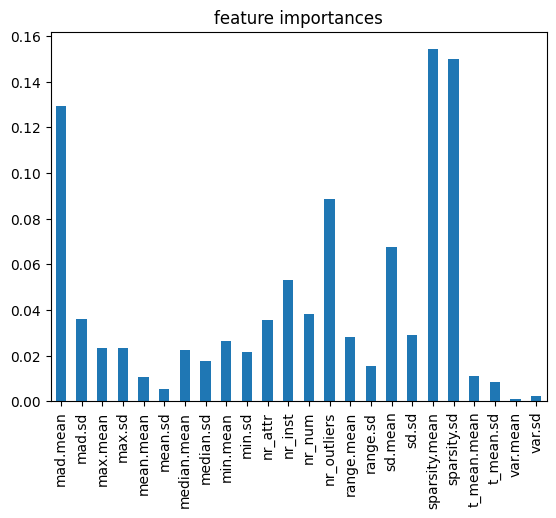

In [11]:
import matplotlib.pyplot as plt


def picture(fi):
    fi.plot(kind='bar')
    plt.title('feature importances')
    plt.show()
    return


fi = pd.Series(rf.feature_importances_, index=X_train.columns)
picture(fi)

In [14]:
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import optuna
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score, classification_report
import numpy as np
from sklearn.model_selection import train_test_split
import random

data = pd.read_csv('Meta_dataset.csv')
y = data['method_zapolnenia']
X = data.drop('method_zapolnenia', axis = 1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42,
    stratify=y
)
rf = RandomForestClassifier(
    n_estimators=147,
    max_depth=7,
    min_samples_leaf=2,
    max_features=1.0,
    random_state=42,
    oob_score=True,
    bootstrap=True,
    n_jobs=-1
)

rf.fit(X_train, y_train)
# Получаем OOB предсказания для F1-score
oob_predictions = rf.oob_decision_function_

# Для многоклассовой классификации берем класс с максимальной вероятностью
oob_pred = np.argmax(oob_predictions, axis=1)
# Вычисляем F1-score
f1 = f1_score(y_train, oob_pred, average='weighted')
print(f1)
A = classification_report(y_train, oob_pred)
print(A)

0.7142629615361579
              precision    recall  f1-score   support

           0       0.80      0.95      0.87       692
           1       0.00      0.00      0.00        34
           2       0.59      0.25      0.35        64
           3       0.00      0.00      0.00        26
           4       0.00      0.00      0.00        24
           5       0.45      0.36      0.40        81

    accuracy                           0.77       921
   macro avg       0.31      0.26      0.27       921
weighted avg       0.68      0.77      0.71       921



C:\Users\nikit\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\nikit\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\nikit\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

In [15]:
y_pred = rf.predict(X_test)
f1 = f1_score(y_test, y_pred, average='weighted')
print(f1)
A = classification_report(y_test, y_pred)
print(A)

0.7172058098187712
              precision    recall  f1-score   support

           0       0.80      0.97      0.88       173
           1       0.00      0.00      0.00         9
           2       0.80      0.25      0.38        16
           3       0.00      0.00      0.00         6
           4       0.00      0.00      0.00         6
           5       0.46      0.29      0.35        21

    accuracy                           0.77       231
   macro avg       0.34      0.25      0.27       231
weighted avg       0.70      0.77      0.72       231



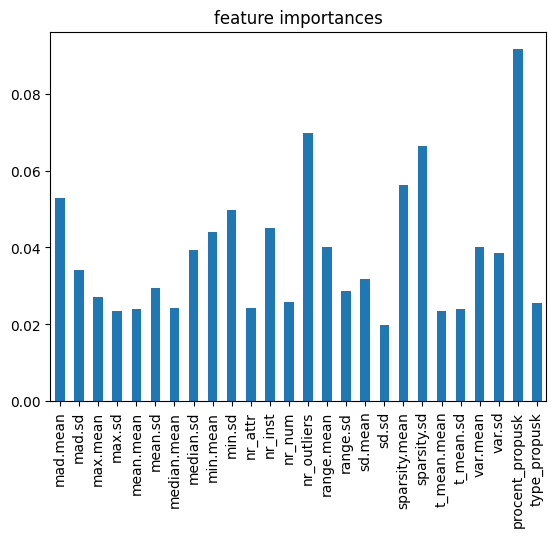

In [16]:
import matplotlib.pyplot as plt


def picture(fi):
    fi.plot(kind='bar')
    plt.title('feature importances')
    plt.show()
    return


fi = pd.Series(rf.feature_importances_, index=X_train.columns)
picture(fi)

In [13]:
import pandas as pd

data = pd.read_csv('Meta_dataset.csv')
y = data['method_zapolnenia']
X = data.drop('method_zapolnenia', axis = 1)
cols = ['mad.mean', 'nr_outliers', 'sparsity.mean', 'sparsity.sd', 'procent_propusk']
print((X.iloc[:, X.columns.get_indexer(cols)]).min())
print((X.iloc[:, X.columns.get_indexer(cols)]).max())

mad.mean           0.000000
nr_outliers        0.000000
sparsity.mean      0.000006
sparsity.sd        0.000000
procent_propusk    5.000000
dtype: float64
mad.mean           1.736738e+06
nr_outliers        7.050000e+02
sparsity.mean      4.780135e-01
sparsity.sd        4.970259e-01
procent_propusk    5.000000e+01
dtype: float64


In [25]:
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import optuna
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score, classification_report
import numpy as np
from sklearn.model_selection import train_test_split
import random

COUNT_OBJECT = 5
random.seed(42)

data = pd.read_csv('Meta_dataset.csv')
y = data['method_zapolnenia']
X = data.drop('method_zapolnenia', axis = 1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42,
    stratify=y
)

cols = ['mad.mean', 'nr_outliers', 'sparsity.mean', 'sparsity.sd', 'procent_propusk']

positive_values = {
    'mad.mean': 1e10,
    'nr_outliers': 1e5, 
    'sparsity.mean': 2.0,
    'sparsity.sd': 10.0,
    'procent_propusk': 10000
}

# Версия 1: Случайные аномалии из словаря
X_train_1 = X_train.copy()
selected_1 = random.sample(range(len(X_train_1)), 5)

for el in selected_1:
    for col in cols:
        X_train_1.iloc[el, X_train_1.columns.get_loc(col)] = positive_values[col]


X_train_2 = X_train.copy()
selected_2 = random.sample(range(len(X_train_2)), 5)

negative_anomalies = {
    'mad.mean': -100,
    'nr_outliers': -100,
    'sparsity.mean': -100,
    'sparsity.sd': -100,
    'procent_propusk': -100
}

for el in selected_2:
    for col in cols:
        X_train_2.iloc[el, X_train_2.columns.get_loc(col)] = negative_anomalies[col]



rf = RandomForestClassifier(
    n_estimators=147,
    max_depth=7,
    min_samples_leaf=2,
    max_features=1.0,
    random_state=42,
    oob_score=True,
    bootstrap=True,
    n_jobs=-1
)



In [26]:
rf.fit(X_train_1, y_train)
# Получаем OOB предсказания для F1-score
oob_predictions = rf.oob_decision_function_

# Для многоклассовой классификации берем класс с максимальной вероятностью
oob_pred = np.argmax(oob_predictions, axis=1)
# Вычисляем F1-score
f1 = f1_score(y_train, oob_pred, average='weighted')
print(f1)
A = classification_report(y_train, oob_pred)
print(A)

0.7198877196646635
              precision    recall  f1-score   support

           0       0.80      0.96      0.87       692
           1       0.00      0.00      0.00        34
           2       0.62      0.25      0.36        64
           3       0.00      0.00      0.00        26
           4       0.00      0.00      0.00        24
           5       0.49      0.38      0.43        81

    accuracy                           0.77       921
   macro avg       0.32      0.27      0.28       921
weighted avg       0.69      0.77      0.72       921



C:\Users\nikit\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\nikit\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\nikit\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

In [27]:
y_pred = rf.predict(X_test)
f1 = f1_score(y_test, y_pred, average='weighted')
print(f1)
A = classification_report(y_test, y_pred)
print(A)

0.7215761304521808
              precision    recall  f1-score   support

           0       0.81      0.98      0.89       173
           1       0.00      0.00      0.00         9
           2       0.80      0.25      0.38        16
           3       0.00      0.00      0.00         6
           4       0.00      0.00      0.00         6
           5       0.46      0.29      0.35        21

    accuracy                           0.78       231
   macro avg       0.34      0.25      0.27       231
weighted avg       0.70      0.78      0.72       231



C:\Users\nikit\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\nikit\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\nikit\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

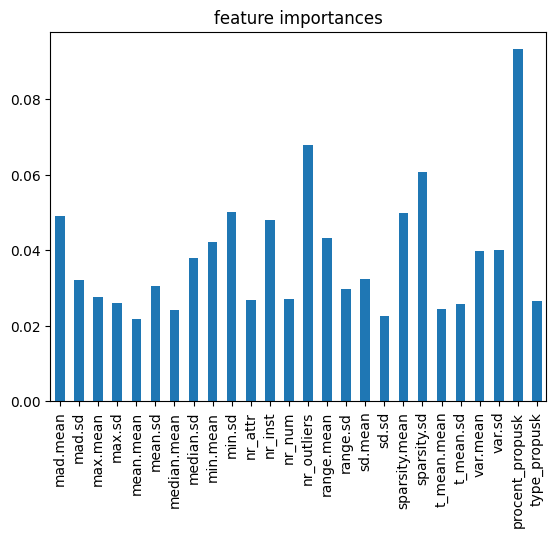

In [28]:
import matplotlib.pyplot as plt


def picture(fi):
    fi.plot(kind='bar')
    plt.title('feature importances')
    plt.show()
    return


fi = pd.Series(rf.feature_importances_, index=X_train_1.columns)
picture(fi)

In [29]:
rf.fit(X_train_2, y_train)
# Получаем OOB предсказания для F1-score
oob_predictions = rf.oob_decision_function_

# Для многоклассовой классификации берем класс с максимальной вероятностью
oob_pred = np.argmax(oob_predictions, axis=1)
# Вычисляем F1-score
f1 = f1_score(y_train, oob_pred, average='weighted')
print(f1)
A = classification_report(y_train, oob_pred)
print(A)

0.7201467022496106
              precision    recall  f1-score   support

           0       0.81      0.96      0.88       692
           1       0.00      0.00      0.00        34
           2       0.59      0.25      0.35        64
           3       0.00      0.00      0.00        26
           4       0.00      0.00      0.00        24
           5       0.47      0.40      0.43        81

    accuracy                           0.77       921
   macro avg       0.31      0.27      0.28       921
weighted avg       0.69      0.77      0.72       921



C:\Users\nikit\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\nikit\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\nikit\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

In [30]:
y_pred = rf.predict(X_test)
f1 = f1_score(y_test, y_pred, average='weighted')
print(f1)
A = classification_report(y_test, y_pred)
print(A)

0.7172058098187712
              precision    recall  f1-score   support

           0       0.80      0.97      0.88       173
           1       0.00      0.00      0.00         9
           2       0.80      0.25      0.38        16
           3       0.00      0.00      0.00         6
           4       0.00      0.00      0.00         6
           5       0.46      0.29      0.35        21

    accuracy                           0.77       231
   macro avg       0.34      0.25      0.27       231
weighted avg       0.70      0.77      0.72       231



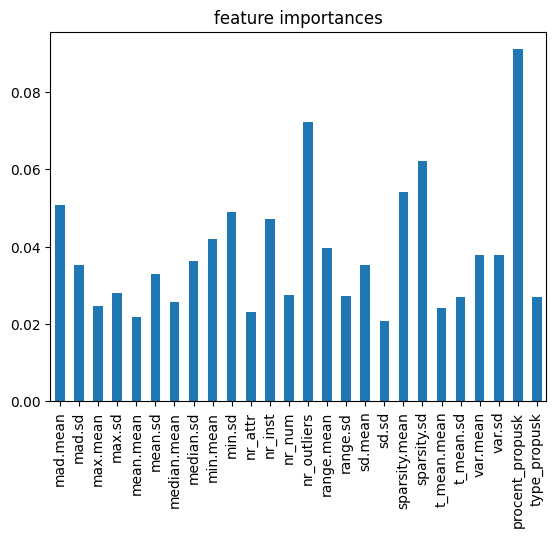

In [31]:
import matplotlib.pyplot as plt


def picture(fi):
    fi.plot(kind='bar')
    plt.title('feature importances')
    plt.show()
    return


fi = pd.Series(rf.feature_importances_, index=X_train_2.columns)
picture(fi)

In [2]:
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import optuna
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score, classification_report
import numpy as np
from sklearn.model_selection import train_test_split


data = pd.read_csv('Meta_dataset.csv')
y = data['method_zapolnenia']
X = data.drop(['method_zapolnenia','type_propusk', 'procent_propusk'], axis = 1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42,
    stratify=y
)

rf = RandomForestClassifier(
    n_estimators=1520,
    max_depth=22,
    min_samples_leaf=11,
    max_features=1.0,
    random_state=42,
    oob_score=True,
    bootstrap=True,
    n_jobs=-1
)

rf.fit(X_train, y_train)
# Получаем OOB предсказания для F1-score
oob_predictions = rf.oob_decision_function_

# Для многоклассовой классификации берем класс с максимальной вероятностью
oob_pred = np.argmax(oob_predictions, axis=1)
# Вычисляем F1-score
f1 = f1_score(y_train, oob_pred, average='weighted')
print(f1)
A = classification_report(y_train, oob_pred)
print(A)

0.7056770677786216
              precision    recall  f1-score   support

           0       0.79      0.98      0.88       692
           1       0.00      0.00      0.00        34
           2       0.86      0.09      0.17        64
           3       0.00      0.00      0.00        26
           4       0.00      0.00      0.00        24
           5       0.54      0.33      0.41        81

    accuracy                           0.78       921
   macro avg       0.36      0.24      0.24       921
weighted avg       0.70      0.78      0.71       921



C:\Users\nikit\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\nikit\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\nikit\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

In [3]:
y_pred = rf.predict(X_test)
f1 = f1_score(y_test, y_pred, average='weighted')
print(f1)
A = classification_report(y_test, y_pred)
print(A)

0.7136612686316438
              precision    recall  f1-score   support

           0       0.79      0.99      0.88       173
           1       0.00      0.00      0.00         9
           2       1.00      0.12      0.22        16
           3       0.00      0.00      0.00         6
           4       0.00      0.00      0.00         6
           5       0.70      0.33      0.45        21

    accuracy                           0.78       231
   macro avg       0.41      0.24      0.26       231
weighted avg       0.72      0.78      0.71       231



C:\Users\nikit\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\nikit\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\nikit\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

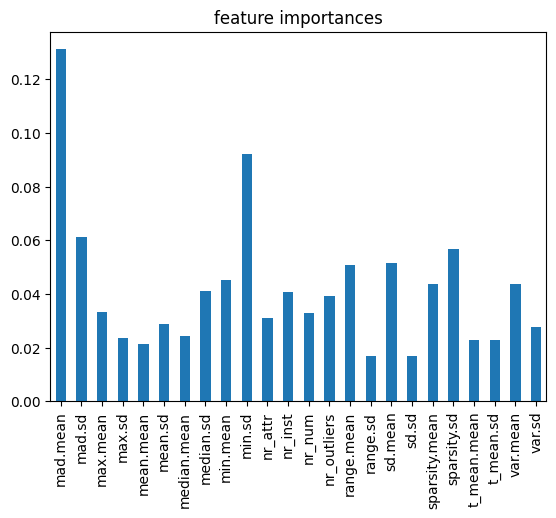

In [4]:
import matplotlib.pyplot as plt


def picture(fi):
    fi.plot(kind='bar')
    plt.title('feature importances')
    plt.show()
    return


fi = pd.Series(rf.feature_importances_, index=X_train.columns)
picture(fi)

In [5]:
import pandas as pd

data = pd.read_csv('Meta_dataset.csv')
y = data['method_zapolnenia']
X = data.drop(['method_zapolnenia','type_propusk', 'procent_propusk'], axis = 1)
cols = ['mad.mean', 'mad.sd', 'min.sd', 'range.mean', 'sd.mean', 'sparsity.sd']
print((X.iloc[:, X.columns.get_indexer(cols)]).min())
print((X.iloc[:, X.columns.get_indexer(cols)]).max())

mad.mean       0.000000
mad.sd         0.000000
min.sd         0.000000
range.mean     0.035776
sd.mean        0.003214
sparsity.sd    0.000000
dtype: float64
mad.mean       1.736738e+06
mad.sd         4.254121e+06
min.sd         5.071665e+07
range.mean     9.436660e+06
sd.mean        1.865653e+06
sparsity.sd    4.970259e-01
dtype: float64


In [9]:
import random

positive_values = {
    'mad.mean': 1e10,
    'mad.sd': 1e10, 
    'min.sd': 1e10,
    'range.mean': 1e10,
    'sd.mean': 1e10,
    'sparsity.sd': 10000
}

# Версия 1: Случайные аномалии из словаря
X_train_1 = X_train.copy()
selected_1 = random.sample(range(len(X_train_1)), 5)

for el in selected_1:
    for col in cols:
        X_train_1.iloc[el, X_train_1.columns.get_loc(col)] = positive_values[col]


X_train_2 = X_train.copy()
selected_2 = random.sample(range(len(X_train_2)), 5)

negative_anomalies = {
    'mad.mean': -100,
    'mad.sd': -100, 
    'min.sd': -100,
    'range.mean': -100,
    'sd.mean': -100,
    'sparsity.sd': -100
}

for el in selected_2:
    for col in cols:
        X_train_2.iloc[el, X_train_2.columns.get_loc(col)] = negative_anomalies[col]

rf = RandomForestClassifier(
    n_estimators=1520,
    max_depth=22,
    min_samples_leaf=11,
    max_features=1.0,
    random_state=42,
    oob_score=True,
    bootstrap=True,
    n_jobs=-1
)

In [10]:
rf.fit(X_train_1, y_train)
# Получаем OOB предсказания для F1-score
oob_predictions = rf.oob_decision_function_

# Для многоклассовой классификации берем класс с максимальной вероятностью
oob_pred = np.argmax(oob_predictions, axis=1)
# Вычисляем F1-score
f1 = f1_score(y_train, oob_pred, average='weighted')
print(f1)
A = classification_report(y_train, oob_pred)
print(A)

0.7060754565378958
              precision    recall  f1-score   support

           0       0.79      0.98      0.87       692
           1       0.00      0.00      0.00        34
           2       0.88      0.11      0.19        64
           3       0.00      0.00      0.00        26
           4       0.00      0.00      0.00        24
           5       0.55      0.32      0.41        81

    accuracy                           0.78       921
   macro avg       0.37      0.24      0.25       921
weighted avg       0.70      0.78      0.71       921



C:\Users\nikit\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\nikit\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\nikit\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

In [11]:
y_pred = rf.predict(X_test)
f1 = f1_score(y_test, y_pred, average='weighted')
print(f1)
A = classification_report(y_test, y_pred)
print(A)

0.7276880728871402
              precision    recall  f1-score   support

           0       0.79      0.99      0.88       173
           1       0.00      0.00      0.00         9
           2       1.00      0.19      0.32        16
           3       0.00      0.00      0.00         6
           4       0.00      0.00      0.00         6
           5       0.80      0.38      0.52        21

    accuracy                           0.79       231
   macro avg       0.43      0.26      0.29       231
weighted avg       0.73      0.79      0.73       231



C:\Users\nikit\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\nikit\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\nikit\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

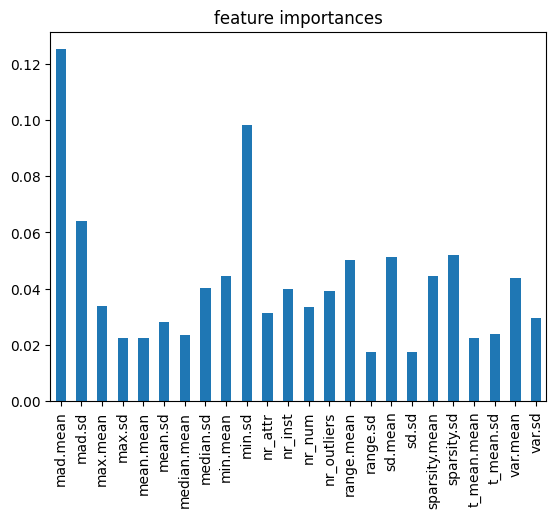

In [12]:
import matplotlib.pyplot as plt


def picture(fi):
    fi.plot(kind='bar')
    plt.title('feature importances')
    plt.show()
    return


fi = pd.Series(rf.feature_importances_, index=X_train_1.columns)
picture(fi)

In [13]:
rf.fit(X_train_2, y_train)
# Получаем OOB предсказания для F1-score
oob_predictions = rf.oob_decision_function_

# Для многоклассовой классификации берем класс с максимальной вероятностью
oob_pred = np.argmax(oob_predictions, axis=1)
# Вычисляем F1-score
f1 = f1_score(y_train, oob_pred, average='weighted')
print(f1)
A = classification_report(y_train, oob_pred)
print(A)

0.710801334705111
              precision    recall  f1-score   support

           0       0.79      0.98      0.88       692
           1       0.00      0.00      0.00        34
           2       0.86      0.09      0.17        64
           3       0.00      0.00      0.00        26
           4       0.00      0.00      0.00        24
           5       0.55      0.38      0.45        81

    accuracy                           0.78       921
   macro avg       0.37      0.24      0.25       921
weighted avg       0.70      0.78      0.71       921



C:\Users\nikit\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\nikit\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\nikit\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

In [14]:
y_pred = rf.predict(X_test)
f1 = f1_score(y_test, y_pred, average='weighted')
print(f1)
A = classification_report(y_test, y_pred)
print(A)

0.7197409486412043
              precision    recall  f1-score   support

           0       0.79      0.99      0.88       173
           1       0.00      0.00      0.00         9
           2       1.00      0.12      0.22        16
           3       0.00      0.00      0.00         6
           4       0.00      0.00      0.00         6
           5       0.73      0.38      0.50        21

    accuracy                           0.79       231
   macro avg       0.42      0.25      0.27       231
weighted avg       0.73      0.79      0.72       231



C:\Users\nikit\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\nikit\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\nikit\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

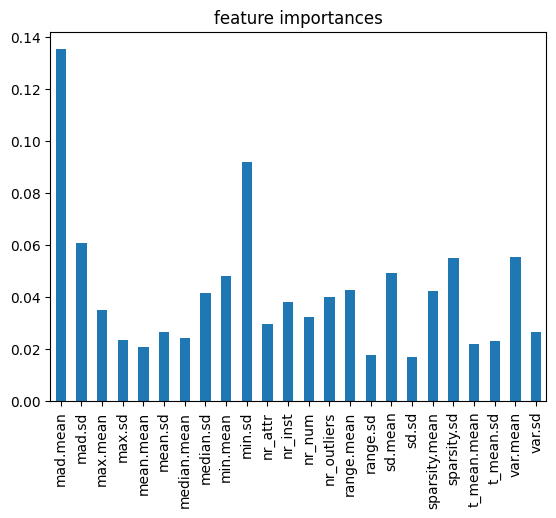

In [15]:
import matplotlib.pyplot as plt


def picture(fi):
    fi.plot(kind='bar')
    plt.title('feature importances')
    plt.show()
    return


fi = pd.Series(rf.feature_importances_, index=X_train_2.columns)
picture(fi)

In [18]:
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import optuna
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
import numpy as np


def objective_classifier(trial, X_train, y_train):
    n_estimators = trial.suggest_int('n_estimators', 50, 2000)
    max_depth = trial.suggest_int('max_depth', 5, 30, log=True)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 40)
    max_features = trial.suggest_categorical(
        'max_features', ["sqrt", 0.25, 1/3, 0.5, 0.7, 1.0])

    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features,
        random_state=42,
        oob_score=True,
        bootstrap=True,
        n_jobs=-1
    )

    model.fit(X_train, y_train)

    return model.oob_score_


def sklearn_importance(X_train, y_train):
    study = optuna.create_study(direction='maximize')
    study.optimize(lambda trial: objective_classifier(
        trial, X_train, y_train), n_trials=100)
    best_params = study.best_params
    rf = RandomForestClassifier(
        **best_params,
        random_state=42,
        oob_score=True,
        bootstrap=True,
        n_jobs=-1
    )
    print(best_params)
    rf.fit(X_train, y_train)
    # Получаем OOB предсказания для F1-score
    oob_predictions = rf.oob_decision_function_
    
    # Для многоклассовой классификации берем класс с максимальной вероятностью
    oob_pred = np.argmax(oob_predictions, axis=1)
    # Вычисляем F1-score
    f1 = f1_score(y_train, oob_pred, average='weighted')
    print(f1)



data = pd.read_csv('Meta_dataset.csv')
y = data['method_zapolnenia']
X = data.drop('method_zapolnenia', axis = 1)
sklearn_importance(X, y)

[I 2025-11-19 13:18:34,838] A new study created in memory with name: no-name-1879cfc1-be3f-4a76-8b95-bedee8b43562
[I 2025-11-19 13:18:37,282] Trial 0 finished with value: 0.7795138888888888 and parameters: {'n_estimators': 596, 'max_depth': 13, 'min_samples_leaf': 12, 'max_features': 0.5}. Best is trial 0 with value: 0.7795138888888888.
[I 2025-11-19 13:18:41,547] Trial 1 finished with value: 0.7751736111111112 and parameters: {'n_estimators': 1108, 'max_depth': 12, 'min_samples_leaf': 18, 'max_features': 0.5}. Best is trial 0 with value: 0.7795138888888888.
[I 2025-11-19 13:18:43,057] Trial 2 finished with value: 0.7803819444444444 and parameters: {'n_estimators': 374, 'max_depth': 9, 'min_samples_leaf': 11, 'max_features': 0.5}. Best is trial 2 with value: 0.7803819444444444.
[I 2025-11-19 13:18:47,222] Trial 3 finished with value: 0.7595486111111112 and parameters: {'n_estimators': 1113, 'max_depth': 21, 'min_samples_leaf': 26, 'max_features': 'sqrt'}. Best is trial 2 with value: 0.

{'n_estimators': 147, 'max_depth': 7, 'min_samples_leaf': 2, 'max_features': 1.0}
0.7383119126300394


In [19]:
data = pd.read_csv('Meta_dataset.csv')
y = data['method_zapolnenia']
X = data.drop(['method_zapolnenia','type_propusk'], axis = 1)
sklearn_importance(X, y)

[I 2025-11-19 13:33:10,086] A new study created in memory with name: no-name-f50d32e7-54fe-48fa-b415-6e4525ce59a2
[I 2025-11-19 13:33:16,111] Trial 0 finished with value: 0.7673611111111112 and parameters: {'n_estimators': 1443, 'max_depth': 10, 'min_samples_leaf': 20, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.7673611111111112.
[I 2025-11-19 13:33:22,242] Trial 1 finished with value: 0.7699652777777778 and parameters: {'n_estimators': 1617, 'max_depth': 5, 'min_samples_leaf': 1, 'max_features': 0.5}. Best is trial 1 with value: 0.7699652777777778.
[I 2025-11-19 13:33:25,435] Trial 2 finished with value: 0.7690972222222222 and parameters: {'n_estimators': 817, 'max_depth': 8, 'min_samples_leaf': 21, 'max_features': 0.25}. Best is trial 1 with value: 0.7699652777777778.
[I 2025-11-19 13:33:26,267] Trial 3 finished with value: 0.7690972222222222 and parameters: {'n_estimators': 179, 'max_depth': 15, 'min_samples_leaf': 3, 'max_features': 0.5}. Best is trial 1 with value: 0.76

{'n_estimators': 957, 'max_depth': 7, 'min_samples_leaf': 1, 'max_features': 0.25}
0.7385861617980708


In [20]:
data = pd.read_csv('Meta_dataset.csv')
y = data['method_zapolnenia']
X = data.drop(['method_zapolnenia','type_propusk', 'procent_propusk'], axis = 1)
sklearn_importance(X, y)

[I 2025-11-19 13:50:44,486] A new study created in memory with name: no-name-e6045659-20db-4733-a587-affc1e807a2f
[I 2025-11-19 13:50:50,374] Trial 0 finished with value: 0.7777777777777778 and parameters: {'n_estimators': 1173, 'max_depth': 16, 'min_samples_leaf': 5, 'max_features': 1.0}. Best is trial 0 with value: 0.7777777777777778.
[I 2025-11-19 13:50:51,063] Trial 1 finished with value: 0.7795138888888888 and parameters: {'n_estimators': 152, 'max_depth': 10, 'min_samples_leaf': 9, 'max_features': 0.5}. Best is trial 1 with value: 0.7795138888888888.
[I 2025-11-19 13:50:51,782] Trial 2 finished with value: 0.7673611111111112 and parameters: {'n_estimators': 178, 'max_depth': 16, 'min_samples_leaf': 25, 'max_features': 0.3333333333333333}. Best is trial 1 with value: 0.7795138888888888.
[I 2025-11-19 13:50:55,105] Trial 3 finished with value: 0.7673611111111112 and parameters: {'n_estimators': 774, 'max_depth': 5, 'min_samples_leaf': 11, 'max_features': 1.0}. Best is trial 1 with 

{'n_estimators': 1520, 'max_depth': 22, 'min_samples_leaf': 11, 'max_features': 1.0}
0.7241344983575821


In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import f1_score, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance


data = pd.read_csv('Meta_dataset.csv')
y = data['method_zapolnenia']
X = data.drop('method_zapolnenia', axis = 1)

# 2. Нормализация
scaler = StandardScaler()
scaled_features = scaler.fit_transform(X)

# 3. Преобразуем обратно в DataFrame (для удобства)
scaled_df = pd.DataFrame(scaled_features, columns=X.columns)

X_train, X_test, y_train, y_test = train_test_split(
    scaled_df, y, 
    test_size=0.2, 
    random_state=42,
    stratify=y
)

model = KNeighborsClassifier(
    n_neighbors=4,
    weights='distance'
)

# Обучаем модель
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

# Вычисляем F1-score
f1 = f1_score(y_test, y_pred, average=None)
print(f1)
f1 = f1_score(y_test, y_pred, average='weighted')
print(f1)
f1 = f1_score(y_test, y_pred, average='micro')
print(f1)
f1 = f1_score(y_test, y_pred, average='macro')
print(f1)

[0.82816901 0.30769231 0.08       0.         0.         0.26086957]
0.6614750263005009
0.6753246753246753
0.24612181449903436


In [5]:
y_pred = model.predict(X_test)
f1 = f1_score(y_test, y_pred, average='weighted')
print(f1)
A = classification_report(y_test, y_pred)
print(A)

0.6614750263005009
              precision    recall  f1-score   support

           0       0.81      0.85      0.83       173
           1       0.50      0.22      0.31         9
           2       0.11      0.06      0.08        16
           3       0.00      0.00      0.00         6
           4       0.00      0.00      0.00         6
           5       0.24      0.29      0.26        21

    accuracy                           0.68       231
   macro avg       0.28      0.24      0.25       231
weighted avg       0.65      0.68      0.66       231



In [6]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import f1_score, classification_report
from sklearn.preprocessing import StandardScaler

data = pd.read_csv('Meta_dataset.csv')
y = data['method_zapolnenia']
X = data.drop(['method_zapolnenia','type_propusk', 'procent_propusk'], axis = 1)


# 2. Нормализация
scaler = StandardScaler()
scaled_features = scaler.fit_transform(X)

# 3. Преобразуем обратно в DataFrame (для удобства)
scaled_df = pd.DataFrame(scaled_features, columns=X.columns)

X_train, X_test, y_train, y_test = train_test_split(
    scaled_df, y, 
    test_size=0.2, 
    random_state=42,
    stratify=y
)

model = KNeighborsClassifier(
    n_neighbors=5,
    weights='distance'
)

# Обучаем модель
model.fit(X_train, y_train)


y_pred = model.predict(X_test)

# Вычисляем F1-score
f1 = f1_score(y_test, y_pred, average=None)
print(f1)
f1 = f1_score(y_test, y_pred, average='weighted')
print(f1)
f1 = f1_score(y_test, y_pred, average='micro')
print(f1)
f1 = f1_score(y_test, y_pred, average='macro')
print(f1)

[0.85302594 0.33333333 0.32258065 0.         0.         0.40909091]
0.7113666079878356
0.7142857142857143
0.31967180403082607


In [8]:
y_pred = model.predict(X_test)
f1 = f1_score(y_test, y_pred, average='weighted')
print(f1)
A = classification_report(y_test, y_pred)
print(A)

0.7113666079878356
              precision    recall  f1-score   support

           0       0.85      0.86      0.85       173
           1       0.33      0.33      0.33         9
           2       0.33      0.31      0.32        16
           3       0.00      0.00      0.00         6
           4       0.00      0.00      0.00         6
           5       0.39      0.43      0.41        21

    accuracy                           0.71       231
   macro avg       0.32      0.32      0.32       231
weighted avg       0.71      0.71      0.71       231



PermutationExplainer explainer: 232it [00:12,  3.91it/s]                                                               


Форма SHAP значений: (231, 24, 6)


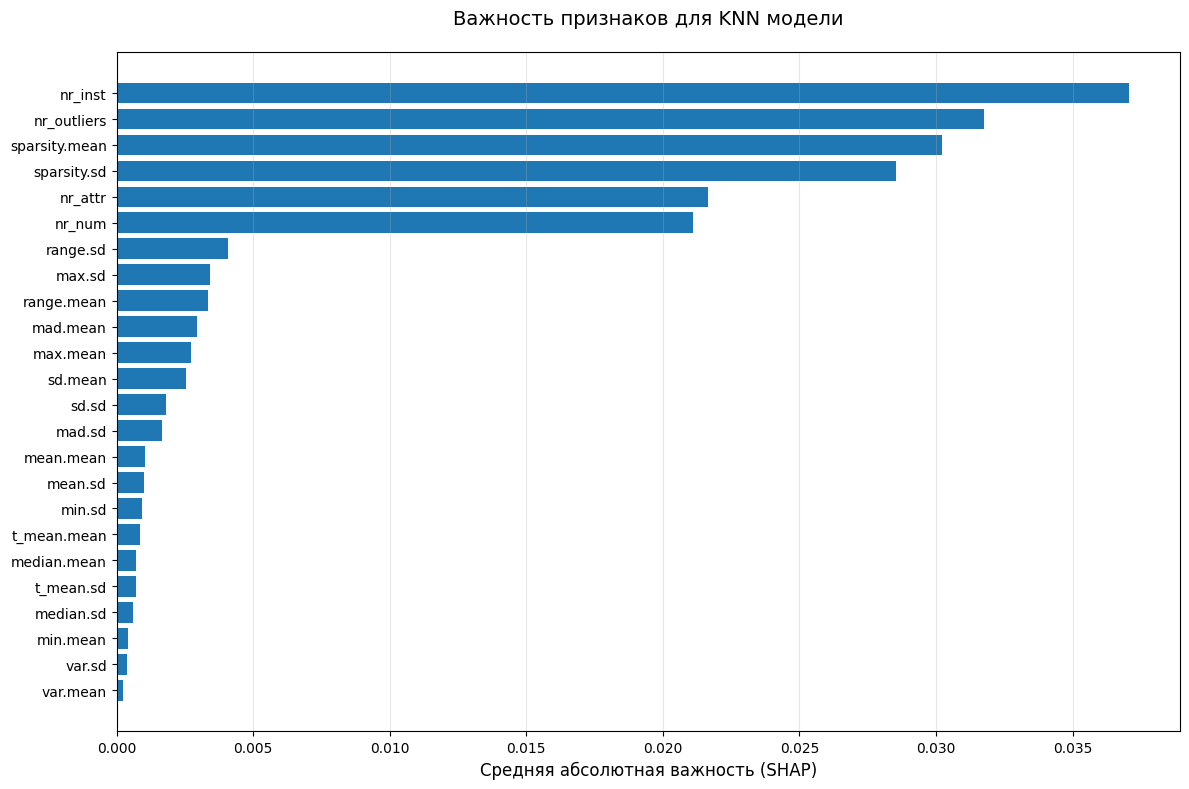


Топ-10 самых важных признаков:
      Признак  Важность
     mad.mean  0.002934
   range.mean  0.003360
       max.sd  0.003420
     range.sd  0.004071
       nr_num  0.021094
      nr_attr  0.021663
  sparsity.sd  0.028548
sparsity.mean  0.030223
  nr_outliers  0.031745
      nr_inst  0.037077


In [12]:
import shap
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# 1. Выбираем небольшое количество данных для ускорения
background_sample = X_train
test_sample = X_test

# 2. Используем PermutationExplainer (быстрее для KNN)
explainer = shap.PermutationExplainer(
    model.predict_proba,
    background_sample,
    max_evals=100
)

# 3. Вычисляем SHAP значения
shap_values = explainer(test_sample)

# 4. Извлекаем значения из объекта Explanation
shap_values_array = shap_values.values

# 5. Вычисляем важность признаков (среднее абсолютное значение)
# Проверяем форму массива
print(f"Форма SHAP значений: {shap_values_array.shape}")

# Вычисляем важность в зависимости от формы
if len(shap_values_array.shape) == 3:
    # Форма: (образцы, признаки, классы)
    # Среднее по всем образцам и классам
    feature_importance = np.abs(shap_values_array).mean(axis=(0, 2))
else:
    # Форма: (образцы, признаки)
    # Среднее по всем образцам
    feature_importance = np.abs(shap_values_array).mean(axis=0)

# 6. Создаем DataFrame с важностью
importance_df = pd.DataFrame({
    'Признак': X.columns,
    'Важность': feature_importance
}).sort_values('Важность', ascending=True)  # сортируем для горизонтального графика

# 7. Строим один график
plt.figure(figsize=(12, 8))
plt.barh(importance_df['Признак'], importance_df['Важность'])
plt.xlabel('Средняя абсолютная важность (SHAP)', fontsize=12)
plt.title('Важность признаков для KNN модели', fontsize=14, pad=20)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# Выводим топ-10 самых важных признаков
print("\nТоп-10 самых важных признаков:")
print(importance_df.tail(10).to_string(index=False))